In [43]:
import aqua

from aqua.batchAQUA_general import batchAQUA
from aqua.utils import *
from aqua.stimulus import *

import numpy as np
import os
import glob
import pickle
import matplotlib.pyplot as plt
import re
import pandas as pd

In [44]:


def plot_neuron_stas_from_files(directory, neuron_id, name="*", mode="*", ax = None):
    """
    Finds files matching a pattern, extracts the frequency, and plots the STA for a specific neuron.
    
    Parameters:
    directory (str): Path to the folder containing your data files.
    neuron_id (int): The index of the neuron to plot.
    name (str): The <name> part of the filename (wildcard default).
    mode (str): The <mode> part of the filename (wildcard default).
    """
    # Pattern to match: <name>_<mode>_<f><file_signature>
    # We use a wildcard for the frequency part to find all files
    file_pattern = os.path.join(directory, f"{name}_{mode}_*_STA.pickle")
    files = glob.glob(file_pattern)
    
    if not files:
        print("No files found matching the pattern.")
        return

    plt.figure(figsize=(10, 6))
    
    # Store data in a list of tuples (frequency, sta_data) so we can sort them
    found_data = []

    for file_path in files:
        filename = os.path.basename(file_path)
        
        # Extract frequency using regex. 
        # This looks for numbers following the second underscore
        match = re.search(rf"{name}_{mode}_(\d+)", filename)
        if match:
            freq = int(match.group(1))
            
            with open(file_path, 'rb') as f:
                file_dict = pickle.load(f)
            
            if neuron_id in file_dict:
                sta_signal = file_dict[neuron_id]['sta']
                found_data.append((freq, sta_signal))
            else:
                print(f"Neuron {neuron_id} not found in file: {filename}")

    # Sort by frequency so the legend and plotting order is correct
    found_data.sort(key=lambda x: x[0])
    # handle the axes object
    if ax is None:
        fig, ax = plt.subplots(figsize = (8, 5))
    
    # plotting
    for freq, sta in found_data:
        ax.plot(sta, label=f'{freq} Hz')

    if not found_data:
        print(f"No STA data found for Neuron {neuron_id} in any files.")
        plt.close()
        return

    ax.set_title(f'STA for Neuron {neuron_id} (e = {np.round(file_dict[neuron_id]['e'], 2)}, f = {np.round(file_dict[neuron_id]['f'], 2)}, tau = {np.round(file_dict[neuron_id]['tau'], 2)})')
    ax.set_xlabel('Time Bins')
    ax.set_ylabel('Amplitude')
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return ax

In [45]:
def plot_multiple_neurons_sta(directory, neuron_ids, f, name="*", mode="*", ax=None):
    """
    Plots the STAs for multiple neurons from a single frequency file.
    
    Parameters:
    directory (str): Path to data.
    neuron_ids (list): List of integers representing neuron indices.
    f (int/float): The specific frequency to plot.
    name (str): Experiment name prefix.
    mode (str): Experiment mode.
    ax (matplotlib.axes): Optional pre-existing axes.
    """
    # Construct the specific filename based on your pattern
    # Format: <name>_<mode>_<f><file_signature>
    # Note: If your file signature is specific (like '.pkl'), replace the '*'
    filename = f"{name}_{mode}_{f}_STA.pickle"
    import glob
    file_list = glob.glob(os.path.join(directory, filename))

    if not file_list:
        print(f"No file found for frequency {f} with pattern {filename}")
        return

    # Load the specific file (assuming the first match is the target)
    with open(file_list[0], 'rb') as file:
        data_dict = pickle.load(file)

    # Handle Axes object
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Iterate through the requested neurons
    for n_id in neuron_ids:
        if n_id in data_dict:
            sta_signal = data_dict[n_id]['sta']
            ax.plot(sta_signal, label=f'e:{np.round(data_dict[n_id]['e'], 2)}, f: {np.round(data_dict[n_id]['f'], 2)}')
        else:
            print(f"Warning: Neuron {n_id} not found in frequency file {f}")

    # Formatting
    ax.set_title(f'STA for Multiple Neurons at {f} Hz')
    ax.set_xlabel('Time Bins')
    ax.set_ylabel('Amplitude')
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.legend() # Moved legend slightly out if list is long
    ax.grid(True, alpha=0.3)

    return ax

In [46]:
with open("RS_intHD_uniform//RS_intHD_uniform_6.0_STA.pickle", 'rb') as file:
    data = pickle.load(file)

df = pd.DataFrame.from_dict(data, orient = 'index')
df.index.name = 'neuron_index'
df = df.reset_index()
df = df.round(2)
print(len(df))
print(df.head())

501
   neuron_index    e     f  tau  autapse current  autapse delay  \
0             0  0.0   0.0  0.0              NaN            NaN   
1             1  0.1  50.0  0.0            500.0           6.93   
2             2  0.1  50.0  1.0            500.0           7.93   
3             3  0.1  50.0  2.0            500.0           8.93   
4             4  0.1  50.0  3.0            500.0           9.93   

                                                 sta  
0  [-1.7027320028520216, -1.7003841433802953, -1....  
1  [-2.3579001259267933, -2.355250364867698, -2.3...  
2  [-2.344673661596959, -2.3418894282670033, -2.3...  
3  [-2.3427745844603125, -2.3396997825816737, -2....  
4  [-2.328826910793544, -2.325674552230143, -2.32...  


<Axes: title={'center': 'STA for Neuron 464 (e = 0.19, f = 250.0, tau = 3.0)'}, xlabel='Time Bins', ylabel='Amplitude'>

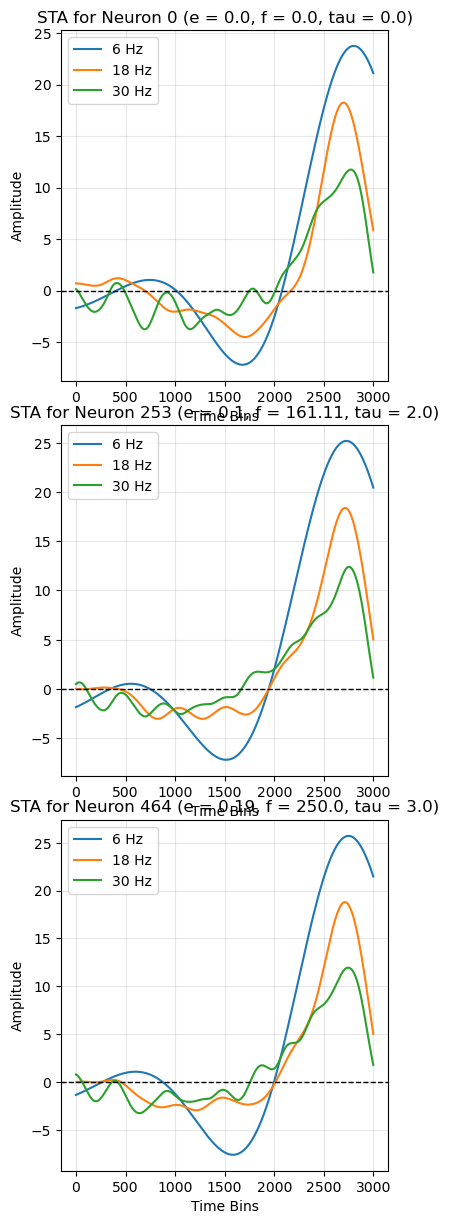

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [47]:
# import the data file
directory = ".//RS_intHD_uniform//"
neuron_ids = [0, 253, 464]

name = 'RS_intHD'
mode = 'uniform'
fig, ax = plt.subplots(3, 1, figsize = (4, 12))
fig.tight_layout()

plot_neuron_stas_from_files(directory, neuron_ids[0], name, mode, ax = ax[0])
plot_neuron_stas_from_files(directory, neuron_ids[1], name, mode, ax = ax[1])
plot_neuron_stas_from_files(directory, neuron_ids[2], name, mode, ax = ax[2])


<Axes: title={'center': 'STA for Multiple Neurons at 30.0 Hz'}, xlabel='Time Bins', ylabel='Amplitude'>

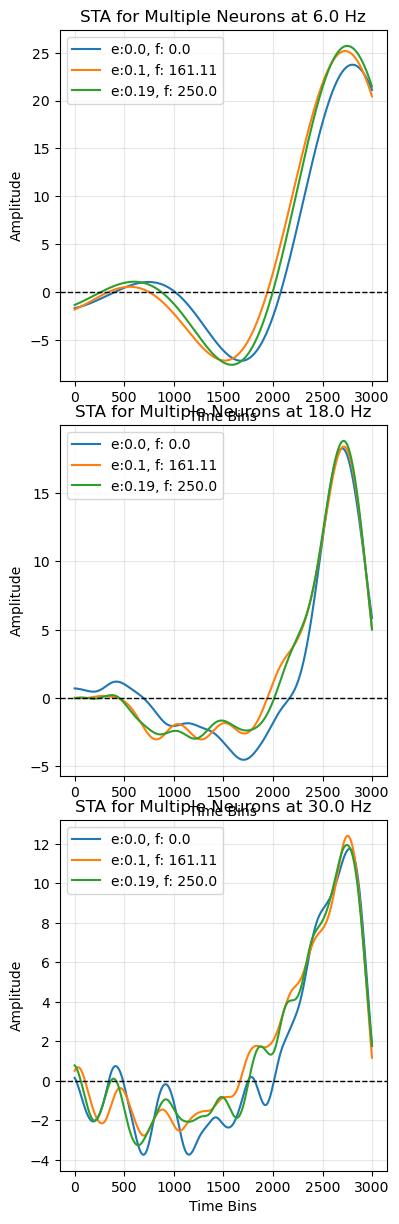

In [48]:
# import the data file
directory = ".//RS_intHD_uniform//"
fs = ['6.0', '18.0', '30.0']
name = 'RS_intHD'
mode = 'uniform'
fig, ax = plt.subplots(3, 1, figsize = (4, 12))
fig.tight_layout()

plot_multiple_neurons_sta(directory, neuron_ids, fs[0], name, mode, ax = ax[0])
plot_multiple_neurons_sta(directory, neuron_ids, fs[1], name, mode, ax = ax[1])
plot_multiple_neurons_sta(directory, neuron_ids, fs[2], name, mode, ax = ax[2])

<Axes: title={'center': 'STA for Neuron 464 (e = 0.19, f = 250.0, tau = 3.0)'}, xlabel='Time Bins', ylabel='Amplitude'>

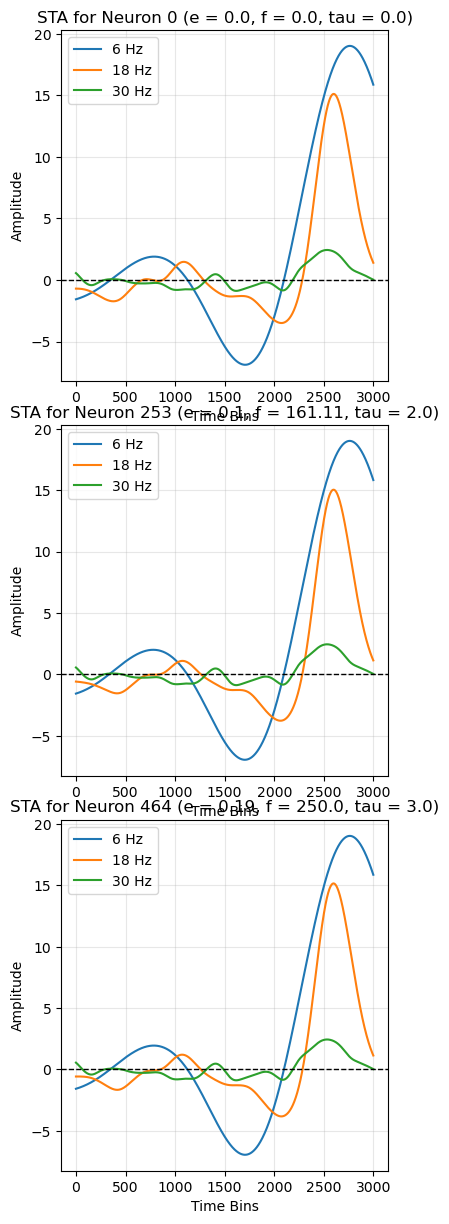

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [49]:
# import the data file
directory = ".//RS_resHD_uniform//"
neuron_id = 0

name = 'RS_resHD'
mode = 'uniform'
fig, ax = plt.subplots(3, 1, figsize = (4, 12))
fig.tight_layout()

plot_neuron_stas_from_files(directory, neuron_ids[0], name, mode, ax = ax[0])
plot_neuron_stas_from_files(directory, neuron_ids[1], name, mode, ax = ax[1])
plot_neuron_stas_from_files(directory, neuron_ids[2], name, mode, ax = ax[2])

<Axes: title={'center': 'STA for Multiple Neurons at 30.0 Hz'}, xlabel='Time Bins', ylabel='Amplitude'>

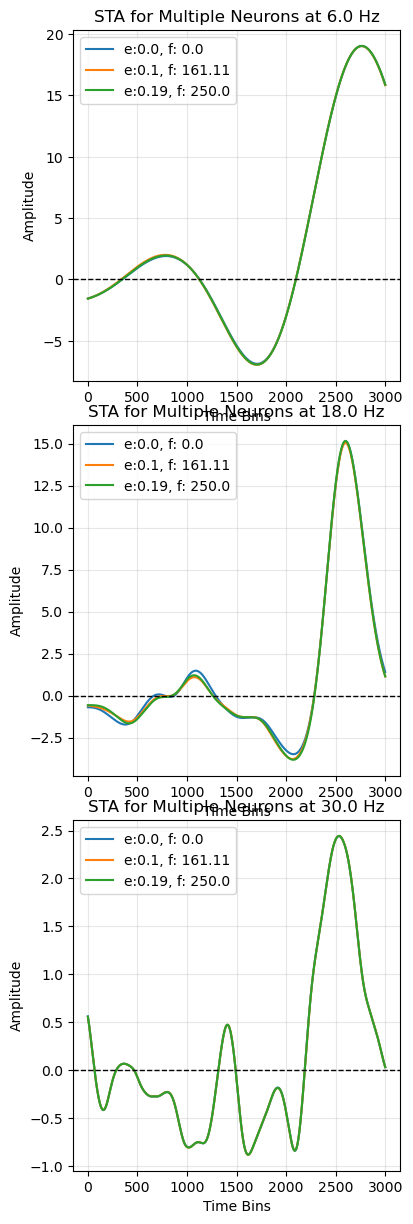

In [50]:
# import the data file
directory = ".//RS_resHD_uniform//"
fs = ['6.0', '18.0', '30.0']
name = 'RS_resHD'
mode = 'uniform'
fig, ax = plt.subplots(3, 1, figsize = (4, 12))
fig.tight_layout()

plot_multiple_neurons_sta(directory, neuron_ids, fs[0], name, mode, ax = ax[0])
plot_multiple_neurons_sta(directory, neuron_ids, fs[1], name, mode, ax = ax[1])
plot_multiple_neurons_sta(directory, neuron_ids, fs[2], name, mode, ax = ax[2])